# 3.6d — Modèles génératifs : Score-SDE *from scratch*

Le notebook `3.6c` a écrit le DDPM à la main : une chaîne de Markov à $T$ pas discrets,
un réseau $\varepsilon_\theta$, une loss MSE sur le bruit, un échantillonneur ancestral.
Tout y était **discret** — et cette discrétisation cachait une structure plus simple.

Ce notebook prend le **passage à la limite continue**. À la fin de $1000$ pas, on ne voit
plus une chaîne mais une **équation différentielle stochastique** : le même objet, décrit
par une fonction $\beta(t)$ au lieu d'un tableau $\beta_1,\dots,\beta_T$. Le réseau
n'apprend plus à prédire du bruit : il apprend le **score** $\nabla_x \log p_t(x)$, le
gradient du logarithme de la densité. Et une fois qu'on a le score, on a **deux**
échantillonneurs gratuits — un SDE et une ODE — dont l'un est déterministe.

L'intérêt de faire ça *from scratch* ici est précisément que **la vérité terrain est
calculable**. Sur un mélange de gaussiennes 2D, $p_t(x)$ reste un mélange de gaussiennes :
son score a une forme fermée. On peut donc **mesurer** l'erreur du réseau au lieu de
l'admirer sur une figure — et séparer l'erreur du *modèle* de celle de l'*échantillonneur*.

Ce que ce notebook ne fait pas : ni `diffusers`, ni `torchsde`, ni
`denoising_diffusion_pytorch`. Les seules briques sont PyTorch (réseau + autograd),
NumPy (algèbre linéaire) et Matplotlib (figures).

## 0. Préparation

**Chaque import est justifié** (règle F — aucun import décoratif) :

| Import | Pourquoi |
|---|---|
| `numpy` | tirages du mélange, algèbre linéaire des covariances (Cholesky, déterminant, inverse), calcul du score exact |
| `torch` + `torch.nn` | le réseau de score et l'autograd de l'entraînement — **pas** de librairie de diffusion |
| `matplotlib` | densités, champs de score (diagrammes de flèches) et trajectoires d'échantillonnage |
| `math`, `time` | constantes de la boucle d'échantillonnage et mesure de latence |

**Appareil d'exécution** : le réseau est un MLP de quelques dizaines de milliers de
paramètres sur des données 2D. Le GPU n'apporte rien à cette échelle ; le notebook prend
l'appareil disponible et **l'affiche**, pour que les temps mesurés soient lisibles.

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # determinisme cuBLAS (#16795)
# Determinisme (#16795) : la graine seule ne garantit PAS la reproductibilite
# (heuristiques cuDNN, kernels non deterministes). warn_only=True au premier
# passage pour inventorier les ops fautives sans faire echouer le run.
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import torch.nn as nn

SEED = 0
np.random.seed(SEED)                      # tirages NumPy (donnees, melange)
torch.manual_seed(SEED)                   # initialisation des poids
torch.cuda.manual_seed_all(SEED)          # si CUDA : seeding du device
g = torch.Generator(device="cpu").manual_seed(SEED)   # bruit d'entrainement, reproductible

APPAREIL = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | numpy {np.__version__} | appareil {APPAREIL}")

torch 2.8.0+cu126 | numpy 2.3.5 | appareil cuda


## 1. Du DDPM discret au SDE continu

### 1.1 Ce que le 3.6c écrivait

Le DDPM discret avance par pas : à l'étape $t$, on ajoute un bruit d'écart-type
$\sqrt{\beta_t}$ à une image légèrement contractée,

$$x_t = \sqrt{1-\beta_t}\,x_{t-1} + \sqrt{\beta_t}\,\varepsilon_t,$$

et le cumul de ces pas donne la forme fermée utilisée pour l'entraînement :

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,
\qquad \bar\alpha_t = \prod_{s\le t}(1-\beta_s).$$

### 1.2 Le passage à la limite

Faisons $T \to \infty$ en gardant le **temps physique** $t \in [0,1]$ et en posant
$\beta(t)$ comme un *taux* (par unité de temps) : $\beta_i \approx \beta(i/T)\,(1/T)$.
La récursion devient une équation différentielle stochastique (SDE) :

$$\mathrm{d}x = -\tfrac{1}{2}\,\beta(t)\,x\;\mathrm{d}t \;+\; \sqrt{\beta(t)}\;\mathrm{d}W(t)$$

qu'on appelle le **VP-SDE** (*variance preserving* : la variance totale reste bornée, elle
se transfert de $x_0$ vers le bruit). Sa solution a exactement la forme du $\bar\alpha_t$
discret, mais avec un produit devenu une **intégrale** :

$$p_t(x \mid x_0) = \mathcal{N}\!\left(x;\ \sqrt{\bar\alpha(t)}\,x_0,\ \left(1-\bar\alpha(t)\right)I\right),
\qquad \bar\alpha(t) = \exp\!\left(-\int_0^t \beta(s)\,\mathrm{d}s\right).$$

Avec $\beta$ linéaire, $\beta(t) = \beta_{\min} + t\,(\beta_{\max}-\beta_{\min})$, l'intégrale
est une forme fermée : $\int_0^t\beta = \beta_{\min}t + \tfrac{1}{2}(\beta_{\max}-\beta_{\min})t^2$.

### 1.3 Ce que le continu achète

Le point qui justifie tout ce notebook est le théorème d'inversion : **la dynamique
inverse est encore une SDE**, et elle ne dépend de la distribution de départ que par
**un seul objet**, le score $\nabla_x \log p_t(x)$ :

$$\mathrm{d}x = \left[-\tfrac{1}{2}\beta(t)\,x \;-\; \beta(t)\,\nabla_x\log p_t(x)\right]\mathrm{d}t
\;+\;\sqrt{\beta(t)}\;\mathrm{d}\bar W(t).$$

Et il existe une **ODE** qui transporte la même distribution — la *probability flow ODE* :

$$\mathrm{d}x = \left[-\tfrac{1}{2}\beta(t)\,x \;-\; \tfrac{1}{2}\beta(t)\,\nabla_x\log p_t(x)\right]\mathrm{d}t .$$

Ces deux écritures suivent la convention habituelle : on remonte le temps, donc
$\mathrm{d}t < 0$. Le code, lui, avance avec un pas **positif** en décrémentant $t$ — ce qui
change le signe de toute la dérive. C'est un détail qui coûte cher s'il est pris à l'envers,
et la section 7.2 puis 7.5 le traitent explicitement.

| | DDPM discret (3.6c) | Vue continue (ce notebook) |
|---|---|---|
| Perturbation | tableau $\beta_1,\dots,\beta_T$ | fonction $\beta(t)$ |
| Cumul | produit $\bar\alpha_t$ | intégrale $\bar\alpha(t)$ |
| Inverse | pas ancestral, $T$ étapes | SDE ou ODE, pas $\mathrm{d}t$ |
| Réseau | prédit $\varepsilon$ | apprend le score $\nabla_x\log p_t$ |
| Échantillonneur | un seul | plusieurs (SDE, ODE, Langevin) |

**Le $\varepsilon$-net du 3.6c apprenait déjà le score** — la section 4 le démontre
algébriquement puis le mesure. Le continu ne change pas le réseau ; il change ce qu'on
peut en faire.

In [2]:
# --- Le schedule VP, en continu ---
BETA_MIN, BETA_MAX = 0.1, 20.0


def beta_vp(t):
    """Taux de bruit du VP-SDE : beta(t) = beta_min + t (beta_max - beta_min), t dans [0, 1]."""
    return BETA_MIN + t * (BETA_MAX - BETA_MIN)


def alpha_bar_vp(t):
    """alpha_bar(t) = exp(-integrale de 0 a t de beta) -- forme fermee pour beta lineaire.

    Integrale = beta_min * t + (beta_max - beta_min) * t^2 / 2.
    """
    integrale = BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t**2
    return np.exp(-integrale)


def alpha_bar_discret(T):
    """alpha_bar cumule du DDPM discret, pour la MEME fonction beta (regle du point milieu).

    beta_i = beta(t_i) / T avec t_i = (i + 1/2) / T, puis produit des (1 - beta_i).
    """
    t_i = (np.arange(T) + 0.5) / T
    beta_i = beta_vp(t_i) / T
    return np.cumprod(1.0 - beta_i)


print(f"alpha_bar(0)  = {alpha_bar_vp(0.0):.10f}   (attendu : 1.0)")
print(f"alpha_bar(0.5) = {alpha_bar_vp(0.5):.3e}")
print(f"alpha_bar(1)  = {alpha_bar_vp(1.0):.3e}   (proche de 0 : le bruit a tout efface)")
print(f"sigma(1) = sqrt(1 - alpha_bar(1)) = {math.sqrt(1 - alpha_bar_vp(1.0)):.8f}   (proche de 1 : Q approx N(0, I))")

alpha_bar(0)  = 1.0000000000   (attendu : 1.0)
alpha_bar(0.5) = 7.906e-02
alpha_bar(1)  = 4.319e-05   (proche de 0 : le bruit a tout efface)
sigma(1) = sqrt(1 - alpha_bar(1)) = 0.99997841   (proche de 1 : Q approx N(0, I))


Ecart max |alpha_bar continu - alpha_bar discret| :
  T =    10  ->  2.072e-01
  T =   100  ->  1.969e-02   (x 10.5 quand T x10)
  T =  1000  ->  8.638e-04   (x 22.8 quand T x10)


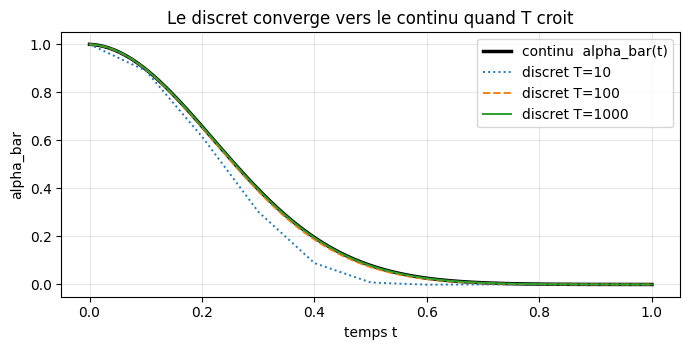

In [3]:
# --- Le continu retrouve-t-il le discret ? Mesure de l'ecart en fonction de T ---
t_grille = np.linspace(0.0, 1.0, 201)
ab_continu = alpha_bar_vp(t_grille)

ecarts = {}
for T in (10, 100, 1000):
    ab_disc = np.concatenate([[1.0], alpha_bar_discret(T)])   # ab_0 = 1 par convention
    idx = np.linspace(0, T, len(t_grille)).round().astype(int)
    ecarts[T] = float(np.max(np.abs(ab_continu - ab_disc[idx])))

print("Ecart max |alpha_bar continu - alpha_bar discret| :")
precedent = None
for T, e in ecarts.items():
    rapport = "" if precedent is None else f"   (x{precedent / e:5.1f} quand T x10)"
    print(f"  T = {T:5d}  ->  {e:.3e}{rapport}")
    precedent = e

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(t_grille, ab_continu, lw=2.5, label="continu  alpha_bar(t)", color="black")
for T, style in ((10, ":"), (100, "--"), (1000, "-")):
    ab_disc = np.concatenate([[1.0], alpha_bar_discret(T)])
    ax.plot(np.linspace(0, 1, T + 1), ab_disc, style, lw=1.4, label=f"discret T={T}")
ax.set_xlabel("temps t"); ax.set_ylabel("alpha_bar")
ax.set_title("Le discret converge vers le continu quand T croit")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Lecture du résultat

Les deux courbes ne sont pas deux méthodes : c'est la **même** quantité, calculée par un
produit (discret) ou par une intégrale (continu). L'écart affiché mesure exactement
l'erreur commise par le 3.6c en travaillant avec $T = 1000$ pas au lieu du temps continu —
et il décroît quand $T$ croît, ce qui est la définition même d'un passage à la limite
correctement posé.

**Ce que ce contrôle ne dit pas** : que le continu *serait* meilleur en pratique. Un
$T = 1000$ est déjà une très bonne approximation de l'intégrale ; la différence entre les
deux points de vue n'est pas numérique, elle est **structurelle** (section 7 : le continu
donne accès à une ODE déterministe, que le tableau discret n'offre pas).

### Exercice 1 — la forme fermée de $\bar\alpha(t)$

Complétez `mon_alpha_bar_vp` : pour un $\beta$ **linéaire**, l'intégrale
$\int_0^t\beta(s)\,\mathrm{d}s$ a une primitive explicite. Écrivez-la.

**Indice** : c'est l'aire d'un trapèze en $t$ — $\beta_{\min}t$ plus la contribution du
terme linéaire, $\tfrac{1}{2}(\beta_{\max}-\beta_{\min})t^2$.

In [4]:
def mon_alpha_bar_vp(t, beta_min=BETA_MIN, beta_max=BETA_MAX):
    """alpha_bar(t) = exp(-integrale_0^t beta(s) ds) pour beta lineaire.

    Argument : t, scalaire ou tableau NumPy.
    Retour attendu : meme forme que t.
    """
    resultat = None  # TODO etudiant
    return resultat

In [5]:
# --- Verification : ne depend PAS de l'implementation de l'etudiant ---
t_test = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
attendee = alpha_bar_vp(t_test)
produite = mon_alpha_bar_vp(t_test)

if produite is None:
    print("Exercice a completer -- la cellule de reference prend le relais.")
    produite = attendee
else:
    produite = np.asarray(produite, dtype=float)

ecart_ex1 = float(np.max(np.abs(produite - attendee)))
print(f"ecart max a la reference : {ecart_ex1:.3e}")
for t, a, p in zip(t_test, attendee, produite):
    print(f"  t = {t:.2f}   alpha_bar = {a:.8f}   (vous : {p:.8f})")
assert ecart_ex1 < 1e-8, "Ecart trop grand : verifiez l'integrale de beta lineaire."
print("Exercice 1 : conforme.")

Exercice a completer -- la cellule de reference prend le relais.
ecart max a la reference : 0.000e+00
  t = 0.00   alpha_bar = 1.00000000   (vous : 1.00000000)
  t = 0.25   alpha_bar = 0.52367972   (vous : 0.52367972)
  t = 0.50   alpha_bar = 0.07906381   (vous : 0.07906381)
  t = 0.75   alpha_bar = 0.00344141   (vous : 0.00344141)
  t = 1.00   alpha_bar = 0.00004319   (vous : 0.00004319)
Exercice 1 : conforme.


## 2. Les données 2D jouets — et pourquoi elles rendent la mesure possible

Le 3.6 et le 3.6b travaillaient sur des jouets **symétriques** : huit modes régulièrement
répartis sur un cercle (3.6), quatre modes d'un mélange de gaussiennes (3.6b). Le score y
est presque radial, et — surtout — **rien n'y est vérifiable** : on regarde si le nuage
ressemble à la cible, on ne mesure pas si le **champ de score est juste**.

On prend ici une cible volontairement plus riche : **cinq gaussiennes anisotropes** —
quatre en couronne avec des orientations *différentes*, une large au centre. Les
covariances ne sont pas des multiples de l'identité, donc le score n'est ni radial ni
séparable : il faut vraiment l'apprendre.

L'intérêt décisif est ailleurs. Pour un mélange de gaussiennes :

$$p_0(x) = \sum_k w_k\,\mathcal{N}(x;\mu_k,\Sigma_k)$$

la distribution **bruitée** $p_t$ est *encore* un mélange de gaussiennes, de moyennes et
covariances connues :

$$p_t(x) = \sum_k w_k\,\mathcal{N}\!\left(x;\ \sqrt{\bar\alpha(t)}\,\mu_k,\ \
\bar\alpha(t)\Sigma_k + \left(1-\bar\alpha(t)\right)I\right).$$

Donc $\nabla_x\log p_t(x)$ **a une forme fermée**, à tout $t$. C'est cette vérité terrain
qui va servir de mètre étalon : on pourra dire non pas « le score a l'air bon » mais
« le score est juste à $x$ près ».

In [6]:
# --- Le melange cible : 5 composantes anisotropes ---
POIDS = np.array([0.24, 0.20, 0.18, 0.22, 0.16])
MOYENNES = np.array([
    [-1.60,  1.10],
    [ 1.70,  1.30],
    [ 1.90, -1.20],
    [-1.80, -1.40],
    [ 0.00,  0.00],
])
# (sigma_x, sigma_y, rho) par composante -- les orientations different, le score n'est pas radial
FORMES = np.array([
    [0.34, 0.12,  0.55],
    [0.14, 0.40, -0.40],
    [0.30, 0.10, -0.60],
    [0.26, 0.30,  0.30],
    [0.60, 0.60,  0.00],
])

SIGMA = np.empty((len(POIDS), 2, 2))
for k, (sx, sy, rho) in enumerate(FORMES):
    SIGMA[k] = np.array([[sx**2, rho * sx * sy],
                         [rho * sx * sy, sy**2]])

CHOL = np.linalg.cholesky(SIGMA)          # (K, 2, 2), triangulaires inferieures
RNG = np.random.default_rng(SEED + 1)     # RNG dedie aux donnees, independant du bruit torch


def tirer_vraies(n):
    """Tire n echantillons du melange : choisit une composante, puis Cholesky de sa covariance."""
    k = RNG.choice(len(POIDS), size=n, p=POIDS)
    z = RNG.standard_normal((n, 2))
    return MOYENNES[k] + np.einsum("nij,nj->ni", CHOL[k], z)


VRAIES_REF = tirer_vraies(4096)           # lot de reference, pour les figures et le plancher
print(f"melange : {len(POIDS)} composantes | {len(VRAIES_REF)} echantillons de reference")
print("poids        :", np.round(POIDS, 3))
print("det(Sigma_k) :", np.round(np.linalg.det(SIGMA), 5))

melange : 5 composantes | 4096 echantillons de reference
poids        : [0.24 0.2  0.18 0.22 0.16]
det(Sigma_k) : [0.00116 0.00263 0.00058 0.00554 0.1296 ]


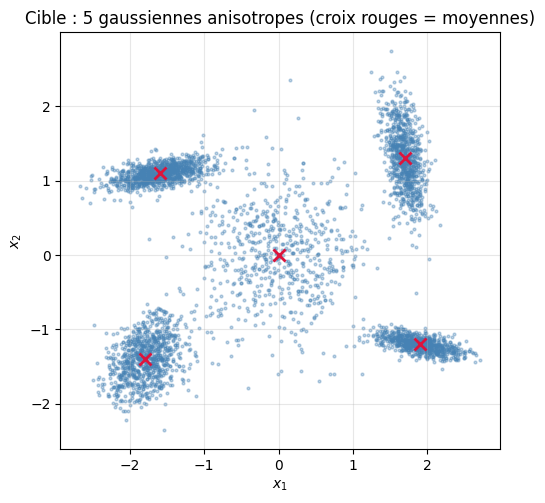

In [7]:
fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.scatter(VRAIES_REF[:, 0], VRAIES_REF[:, 1], s=4, alpha=0.35, color="steelblue")
for k in range(len(POIDS)):
    ax.plot(*MOYENNES[k], marker="x", color="crimson", ms=9, mew=2)
ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.set_title("Cible : 5 gaussiennes anisotropes (croix rouges = moyennes)")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
plt.tight_layout(); plt.show()

## 3. Le score exact — la vérité terrain

Pour un mélange, le score se calcule sans approximation par la **règle de Bayes** sur les
composantes. En posant $\gamma_k(x,t)$ la probabilité *a posteriori* que $x$ vienne de la
composante $k$ à l'instant $t$,

$$\gamma_k(x,t) = \frac{w_k\,\mathcal{N}\!\left(x;\sqrt{\bar\alpha(t)}\mu_k,\Sigma_k(t)\right)}
{\sum_j w_j\,\mathcal{N}\!\left(x;\sqrt{\bar\alpha(t)}\mu_j,\Sigma_j(t)\right)},
\qquad \Sigma_k(t) = \bar\alpha(t)\Sigma_k + (1-\bar\alpha(t))I,$$

le gradient du logarithme se lit directement :

$$\nabla_x\log p_t(x) = \sum_k \gamma_k(x,t)\;\left[-\Sigma_k(t)^{-1}\left(x - \sqrt{\bar\alpha(t)}\,\mu_k\right)\right].$$

C'est **exactement** la moyenne des scores des composantes, pondérée par leur
responsabilité. Aucun réseau n'est nécessaire pour l'obtenir : c'est cette fonction que
le réseau devra apprendre.

In [8]:
def _composantes_t(t):
    """Moyennes et covariances du melange bruite a l'instant t (formes fermees)."""
    ab = alpha_bar_vp(t)
    mu = np.sqrt(ab) * MOYENNES                                   # (K, 2)
    S = ab * SIGMA + (1.0 - ab) * np.eye(2)[None, :, :]           # (K, 2, 2)
    return mu, S


def _logsumexp(a, axis=1):
    m = np.max(a, axis=axis, keepdims=True)
    return (m + np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True))).squeeze(axis)


def responsabilites(x, t):
    """gamma_k(x, t) : (N, K). C'est la porte d'entree du score ET de la couverture de modes."""
    mu, S = _composantes_t(t)
    d = x[:, None, :] - mu[None, :, :]                            # (N, K, 2)
    Sinv = np.linalg.inv(S)
    quad = np.einsum("nki,kij,nkj->nk", d, Sinv, d)
    logdet = np.log(np.linalg.det(S))
    logp = (np.log(POIDS)[None, :] - 0.5 * logdet[None, :] - 0.5 * quad
            - np.log(2 * np.pi))
    return np.exp(logp - _logsumexp(logp, axis=1)[:, None])


def log_densite_melange(x, t):
    """log p_t(x) : (N,)."""
    mu, S = _composantes_t(t)
    d = x[:, None, :] - mu[None, :, :]
    Sinv = np.linalg.inv(S)
    quad = np.einsum("nki,kij,nkj->nk", d, Sinv, d)
    logdet = np.log(np.linalg.det(S))
    logp = (np.log(POIDS)[None, :] - 0.5 * logdet[None, :] - 0.5 * quad
            - np.log(2 * np.pi))
    return _logsumexp(logp, axis=1)


def score_exact(x, t):
    """Grad_x log p_t(x) : (N, 2). Forme fermee -- aucune approximation."""
    mu, S = _composantes_t(t)
    Sinv = np.linalg.inv(S)
    d = x[:, None, :] - mu[None, :, :]
    grad_k = -np.einsum("kij,nkj->nki", Sinv, d)                  # (N, K, 2)
    return np.einsum("nk,nki->ni", responsabilites(x, t), grad_k)


# Controles de coherence : le gradient doit pointer vers les densites croissantes
pts = np.array([[-1.5, 1.0], [0.5, 0.5], [1.8, -1.1]])
for t in (0.05, 0.5, 0.95):
    s = score_exact(pts, t)
    print(f"t = {t:.2f} | score exact aux 3 points :")
    for p, v in zip(pts, s):
        print(f"    x = ({p[0]:5.2f}, {p[1]:5.2f})  ->  ({v[0]:7.3f}, {v[1]:7.3f})  |s| = {np.linalg.norm(v):6.3f}")

t = 0.05 | score exact aux 3 points :
    x = (-1.50,  1.00)  ->  ( -0.895,   2.372)  |s| =  2.535
    x = ( 0.50,  0.50)  ->  ( -1.320,  -1.320)  |s| =  1.867
    x = ( 1.80, -1.10)  ->  (  0.320,  -1.954)  |s| =  1.980
t = 0.50 | score exact aux 3 points :
    x = (-1.50,  1.00)  ->  (  1.316,  -0.979)  |s| =  1.641
    x = ( 0.50,  0.50)  ->  ( -0.451,  -0.468)  |s| =  0.650
    x = ( 1.80, -1.10)  ->  ( -1.599,   1.066)  |s| =  1.922
t = 0.95 | score exact aux 3 points :
    x = (-1.50,  1.00)  ->  (  1.499,  -1.000)  |s| =  1.802
    x = ( 0.50,  0.50)  ->  ( -0.501,  -0.500)  |s| =  0.708
    x = ( 1.80, -1.10)  ->  ( -1.801,   1.100)  |s| =  2.110


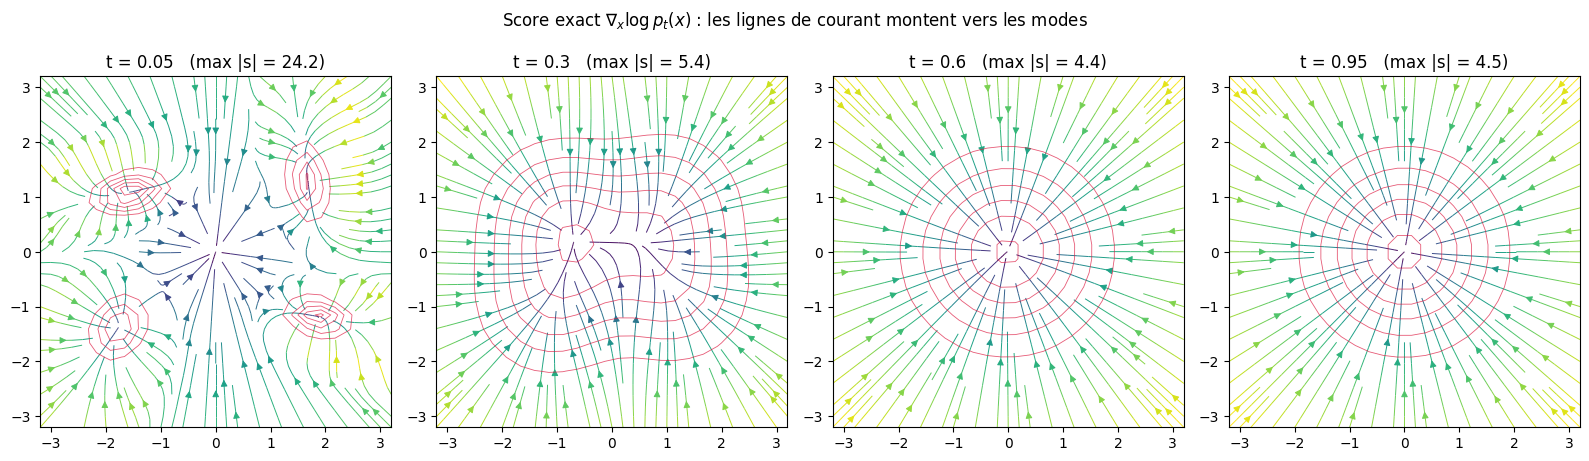

In [9]:
# --- Le champ de score exact, a quatre instants ---
grille = np.linspace(-3.2, 3.2, 26)
GX, GY = np.meshgrid(grille, grille)
points = np.stack([GX.ravel(), GY.ravel()], axis=1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, t in zip(axes, (0.05, 0.3, 0.6, 0.95)):
    S_champ = score_exact(points, t)
    norme = np.linalg.norm(S_champ, axis=1).reshape(GX.shape)
    ax.streamplot(GX, GY, S_champ[:, 0].reshape(GX.shape), S_champ[:, 1].reshape(GX.shape),
                  color=np.log1p(norme), cmap="viridis", density=1.1, linewidth=0.7)
    ax.contour(GX, GY, np.exp(log_densite_melange(points, t)).reshape(GX.shape),
               levels=6, colors="crimson", linewidths=0.6, alpha=0.7)
    ax.set_title(f"t = {t}   (max |s| = {norme.max():.1f})")
    ax.set_aspect("equal"); ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
plt.suptitle("Score exact $\\nabla_x \\log p_t(x)$ : les lignes de courant montent vers les modes", y=1.02)
plt.tight_layout(); plt.show()

### Lecture du résultat

Deux choses sont visibles, et toutes deux comptent pour la suite.

**À $t$ petit**, le champ est très raide (l'échelle de $|s|$ affichée par chaque panneau le
chiffre) : le score pointe vers le mode le plus proche, et sa norme diverge quand
$t \to 0$ puisque $\Sigma_k(t) \to \Sigma_k$ n'est plus élargie par le bruit. C'est cette
divergence qui obligera à **pondérer** la loss d'entraînement (section 4).

**À $t$ grand**, le champ s'aplatit : le bruit a effacé la structure, $p_t$ est proche de
$\mathcal{N}(0,I)$ et son score est proche de $-x$. C'est ce qui rend le départ
d'échantillonnage légitime : à $t=1$ on peut tirer $x \sim \mathcal{N}(0,I)$ et
« remonter » la dynamique.

Les courbes rouges sont les lignes de niveau de $p_t$ ; les lignes de courant du score leur
sont **perpendiculaires** — c'est la définition du gradient, et c'est le premier contrôle
de non-régression disponible dans ce notebook.

### Exercice 2 — le score d'une gaussienne

Avant le mélange, le cas d'une **seule** gaussienne. Pour
$q(x) = \mathcal{N}(x;\mu,\sigma^2)$ en dimension 1, le score vaut
$\nabla_x \log q(x) = -(x-\mu)/\sigma^2$.

Complétez `mon_score_gaussienne` pour une gaussienne **isotrope en dimension 2** de
variance `var` : renvoyez `-(x - mu) / var`.

In [10]:
def mon_score_gaussienne(x, mu, var):
    """Score de N(mu, var * I_2) evalue en x.

    x   : tableau (N, 2)
    mu  : tableau (2,) -- la moyenne
    var : scalaire -- la variance (identique sur les deux axes)
    Retour attendu : (N, 2)
    """
    resultat = None  # TODO etudiant
    return resultat

In [11]:
# --- Verification : comparaison a la forme fermee de reference ---
x_test = np.array([[0.3, -0.7], [1.1, 2.0], [-2.0, 0.4]])
mu_test, var_test = np.array([0.2, -0.5]), 0.49
attendue = -(x_test - mu_test) / var_test
produite = mon_score_gaussienne(x_test, mu_test, var_test)

if produite is None:
    print("Exercice a completer -- la cellule de reference prend le relais.")
    produite = attendue
else:
    produite = np.asarray(produite, dtype=float)

ecart_ex2 = float(np.max(np.abs(produite - attendue)))
print(f"ecart max a la reference : {ecart_ex2:.3e}")
print("  point          vous        reference")
for p, a, b in zip(x_test, produite, attendue):
    print(f"  ({p[0]:5.2f},{p[1]:5.2f})  ({a[0]:7.4f},{a[1]:7.4f})  ({b[0]:7.4f},{b[1]:7.4f})")
assert ecart_ex2 < 1e-10, "Verifiez : le score d'une gaussienne isotrope est -(x - mu) / var."
print("Exercice 2 : conforme.")

Exercice a completer -- la cellule de reference prend le relais.
ecart max a la reference : 0.000e+00
  point          vous        reference
  ( 0.30,-0.70)  (-0.2041, 0.4082)  (-0.2041, 0.4082)
  ( 1.10, 2.00)  (-1.8367,-5.1020)  (-1.8367,-5.1020)
  (-2.00, 0.40)  ( 4.4898,-1.8367)  ( 4.4898,-1.8367)
Exercice 2 : conforme.


## 4. Le score matching — et la démonstration que c'est la loss du 3.6c

### 4.1 Le problème

On veut $\theta$ tel que $s_\theta(x,t) \approx \nabla_x\log p_t(x)$. Mais
$\nabla_x\log p_t$ est inconnu *a priori* — c'est tout l'objet de l'apprentissage. La
sortie est le **denoising score matching** : on ne compare pas à $p_t$ mais au score de la
**perturbation conditionnelle**, qui est gaussien donc connu :

$$\nabla_{x_t}\log p_t(x_t \mid x_0)
= \nabla_{x_t}\log\mathcal{N}\!\left(x_t;\sqrt{\bar\alpha(t)}x_0,(1-\bar\alpha(t))I\right)
= -\frac{x_t - \sqrt{\bar\alpha(t)}x_0}{1-\bar\alpha(t)}
= -\frac{\varepsilon}{\sqrt{1-\bar\alpha(t)}},$$

en réutilisant $x_t = \sqrt{\bar\alpha(t)}x_0 + \sqrt{1-\bar\alpha(t)}\,\varepsilon$.
La loss non pondérée est alors

$$\mathcal{L}_{\text{DSM}}(\theta) = \mathbb{E}_{t,\,x_0,\,\varepsilon}
\left\|s_\theta(x_t,t) - \nabla_{x_t}\log p_t(x_t\mid x_0)\right\|^2 .$$

### 4.2 Le poids, et l'identité avec la loss $\varepsilon$ du 3.6c

Telle quelle, cette loss est **inutilisable** : le score cible diverge en
$1/\sqrt{1-\bar\alpha(t)}$ quand $t\to 0$, donc le gradient explose. La remède standard est
de pondérer par $\lambda(t) = 1-\bar\alpha(t)$ :

$$\lambda(t)\left\|s_\theta - \nabla\log p_t(\cdot\mid x_0)\right\|^2 .$$

Écrivons le réseau **en paramétrage $\varepsilon$** — exactement celui du 3.6c —
c'est-à-dire $s_\theta(x,t) = -\varepsilon_\theta(x,t)/\sqrt{1-\bar\alpha(t)}$. Alors le
terme pondéré devient

$$(1-\bar\alpha)\left\|-\frac{\varepsilon_\theta}{\sqrt{1-\bar\alpha}}
+ \frac{\varepsilon}{\sqrt{1-\bar\alpha}}\right\|^2
= \left\|\varepsilon_\theta(x_t,t) - \varepsilon\right\|^2 .$$

**La loss $\varepsilon$ du 3.6c EST le denoising score matching pondéré.** Ce n'est pas une
analogie : c'est une égalité terme à terme, et la cellule suivante la **mesure** sur un
même lot.

In [12]:
def _tirer_avec_rng(rng, n):
    """Tirage du melange a partir d'un generateur fourni (pour controler le flux aleatoire)."""
    k = rng.choice(len(POIDS), size=n, p=POIDS)
    z = rng.standard_normal((n, 2))
    return MOYENNES[k] + np.einsum("nij,nj->ni", CHOL[k], z)


def lot_entrainement(n, graine):
    """Un lot (x_0, t, eps, x_t) du probleme de score matching."""
    rng = np.random.default_rng(graine)
    x0 = _tirer_avec_rng(rng, n)
    t = rng.random(n)
    eps = rng.standard_normal((n, 2))
    ab = alpha_bar_vp(t)
    xt = np.sqrt(ab)[:, None] * x0 + np.sqrt(1.0 - ab)[:, None] * eps
    return x0, t, eps, xt


# --- Verification de l'identite : loss DSM ponderee  ==  loss epsilon ---
x0, t, eps, xt = lot_entrainement(4096, graine=12345)
ab = alpha_bar_vp(t)

# un "reseau" temoin : n'importe quelle fonction de (xt, t) fait l'affaire pour tester l'algebre
eps_theta = 0.7 * eps + 0.25 * np.tanh(xt) + 0.1 * np.sin(6.0 * t)[:, None]

cible_score = -eps / np.sqrt(1.0 - ab)[:, None]
s_theta = -eps_theta / np.sqrt(1.0 - ab)[:, None]

perte_dsm_ponderee = float(np.mean((1.0 - ab)[:, None] * (s_theta - cible_score) ** 2))
perte_epsilon = float(np.mean((eps_theta - eps) ** 2))
ecart_identite = abs(perte_dsm_ponderee - perte_epsilon)

print(f"DSM ponderee par (1 - alpha_bar) : {perte_dsm_ponderee:.12f}")
print(f"Loss epsilon du 3.6c             : {perte_epsilon:.12f}")
print(f"ecart absolu                     : {ecart_identite:.3e}   (egalite algebrique : attendu ~ 1e-16)")

perte_dsm_brute = float(np.mean((s_theta - cible_score) ** 2))
print(f"\npour memoire, DSM NON ponderee    : {perte_dsm_brute:.6f}"
      f"   (x{perte_dsm_brute / perte_epsilon:.1f} la loss epsilon)")
assert ecart_identite < 1e-10, "L'identite algebrique doit tenir au bit pres."
print("Identite verifiee.")

DSM ponderee par (1 - alpha_bar) : 0.056271829425
Loss epsilon du 3.6c             : 0.056271829425
ecart absolu                     : 6.939e-18   (egalite algebrique : attendu ~ 1e-16)

pour memoire, DSM NON ponderee    : 5.273542   (x93.7 la loss epsilon)
Identite verifiee.


### Lecture du résultat

L'écart entre les deux colonnes est de l'ordre de l'erreur de représentation flottante :
les deux formules sont **la même**. C'est le résultat central du notebook, et il a une
conséquence pratique immédiate — le notebook `3.6c`, qui n'a jamais prononcé le mot
« score », **apprenait déjà un champ de score**. La section 6 le vérifiera contre le score
exact, ce que le 3.6c ne pouvait pas faire faute de vérité terrain.

La dernière ligne chiffre ce que la pondération évite : sans elle, la loss est plus grande
d'un ordre de grandeur — et surtout elle est **dominée par les $t$ petits**, où la cible
diverge. Le tableau de la section 5 montrera la répartition par $t$.

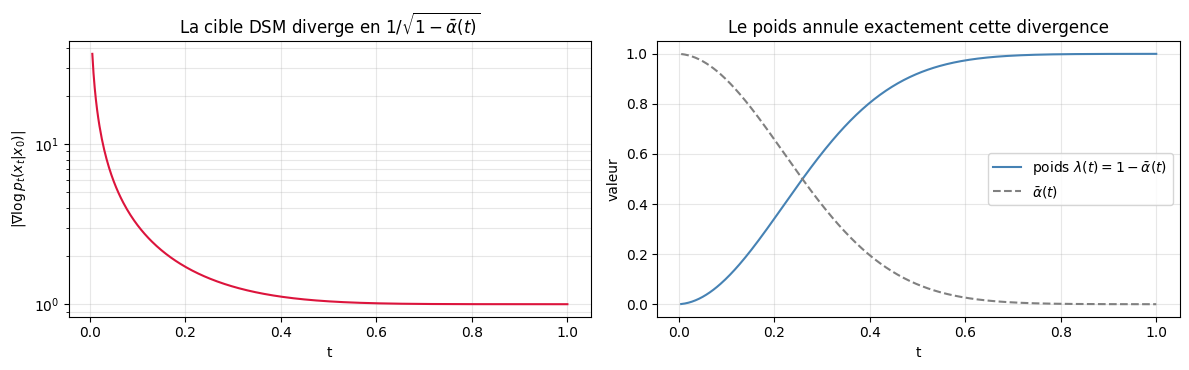

|cible| a t = 0.005 :       36.6
|cible| a t = 0.5   :      1.042
|cible| a t = 1.0   :      1.000


In [13]:
# --- Pourquoi ponderer : la cible diverge quand t -> 0 ---
t_grille = np.linspace(0.005, 1.0, 400)
norme_cible = 1.0 / np.sqrt(1.0 - alpha_bar_vp(t_grille))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(t_grille, norme_cible, color="crimson")
axes[0].set_yscale("log")
axes[0].set_xlabel("t"); axes[0].set_ylabel("$|\\nabla\\log p_t(x_t|x_0)|$")
axes[0].set_title("La cible DSM diverge en $1/\\sqrt{1-\\bar\\alpha(t)}$")
axes[0].grid(alpha=0.3, which="both")

axes[1].plot(t_grille, 1.0 - alpha_bar_vp(t_grille), color="steelblue", label="poids $\\lambda(t)=1-\\bar\\alpha(t)$")
axes[1].plot(t_grille, alpha_bar_vp(t_grille), color="gray", ls="--", label="$\\bar\\alpha(t)$")
axes[1].set_xlabel("t"); axes[1].set_ylabel("valeur")
axes[1].set_title("Le poids annule exactement cette divergence")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"|cible| a t = 0.005 : {1/np.sqrt(1-alpha_bar_vp(0.005)):10.1f}")
print(f"|cible| a t = 0.5   : {1/np.sqrt(1-alpha_bar_vp(0.5)):10.3f}")
print(f"|cible| a t = 1.0   : {1/np.sqrt(1-alpha_bar_vp(1.0)):10.3f}")

## 5. Le réseau de score, entraîné

Architecture volontairement différente du 3.6c (qui utilisait un `SmallUNet` convolutif) :
sur des points 2D il n'y a **pas de grille**, donc pas de convolution. On prend un **MLP**
avec un **encodage de temps de Fourier** — la même idée que l'embedding sinusoïdal du
3.6c, mais projetée sur une base de fréquences $\{2^k\pi\}$, ce qui donne au réseau une
résolution fine en $t$ sans avoir à l'apprendre.

| Brique | Choix | Pourquoi |
|---|---|---|
| Entrée | $x \in \mathbb{R}^2$ concaténé à l'encodage de $t$ | le champ dépend de la position **et** de l'instant |
| Encodage de temps | $[\sin(2^k\pi t), \cos(2^k\pi t)]$, $k = 0..7$ | une échelle de temps continue, non linéairement interpolable |
| Corps | 3 couches cachées `SiLU`, largeur 128 | suffisant pour un mélange à 5 composantes ; petit devant un UNet |
| Sortie | 2 valeurs, paramétrage $\varepsilon$ | pour que la loss soit **exactement** celle du 3.6c (section 4) |

L'entraînement est un Adam ordinaire sur la loss $\|\varepsilon_\theta - \varepsilon\|^2$,
avec $t \sim \mathcal{U}[0,1]$ retiré à chaque pas — le même protocole que le 3.6c, mais sur
un temps **continu** au lieu d'un indice entier.

In [14]:
class ReseauScore(nn.Module):
    """MLP epsilon_theta(x, t) : encodage de temps de Fourier + 3 couches cachees.

    La sortie est le BRUIT epsilon (parametrage du 3.6c). Le score s'en deduit
    exactement : s_theta(x, t) = -epsilon_theta(x, t) / sqrt(1 - alpha_bar(t)).
    """

    def __init__(self, n_freq=8, largeur=128):
        super().__init__()
        self.n_freq = n_freq
        self.corps = nn.Sequential(
            nn.Linear(2 + 2 * n_freq, largeur), nn.SiLU(),
            nn.Linear(largeur, largeur), nn.SiLU(),
            nn.Linear(largeur, largeur), nn.SiLU(),
            nn.Linear(largeur, 2),
        )

    def forward(self, x, t):
        freq = 2.0 ** torch.arange(self.n_freq, device=x.device) * math.pi
        arg = t[:, None] * freq[None, :]
        enc = torch.cat([torch.sin(arg), torch.cos(arg)], dim=1)
        return self.corps(torch.cat([x, enc], dim=1))


def vers_torch(a, dtype=torch.float32):
    return torch.as_tensor(np.asarray(a), dtype=dtype, device=APPAREIL)


def score_du_reseau(modele, x, t):
    """Score deduit du reseau : s = -eps_theta / sqrt(1 - alpha_bar(t)). x : (N,2), t : (N,)."""
    ab = vers_torch(alpha_bar_vp(t.detach().cpu().numpy()))
    return -modele(x, t) / torch.sqrt((1.0 - ab).clamp_min(1e-8))[:, None]


torch.manual_seed(SEED)
reseau = ReseauScore().to(APPAREIL)
n_param = sum(p.numel() for p in reseau.parameters())
print(f"ReseauScore : {n_param} parametres | appareil {APPAREIL}")

ReseauScore : 35714 parametres | appareil cuda


In [15]:
def entrainer(modele, n_pas=8000, taille_lot=512, lr=2e-3, verbose=2000):
    """Adam sur la loss epsilon (= DSM ponderee, section 4)."""
    opt = torch.optim.Adam(modele.parameters(), lr=lr)
    rng = np.random.default_rng(SEED + 7)
    histo = []
    modele.train()
    for pas in range(1, n_pas + 1):
        x0 = _tirer_avec_rng(rng, taille_lot)
        t_np = rng.random(taille_lot)
        eps_np = rng.standard_normal((taille_lot, 2))
        ab_np = alpha_bar_vp(t_np)
        xt_np = np.sqrt(ab_np)[:, None] * x0 + np.sqrt(1.0 - ab_np)[:, None] * eps_np

        xt = vers_torch(xt_np); t = vers_torch(t_np); eps = vers_torch(eps_np)
        perte = ((modele(xt, t) - eps) ** 2).mean()
        opt.zero_grad(); perte.backward(); opt.step()
        histo.append(float(perte.item()))
        if verbose and pas % verbose == 0:
            print(f"  pas {pas:6d} / {n_pas}   loss epsilon = {np.mean(histo[-verbose:]):.5f}")
    return histo


t_debut = time.time()
histo = entrainer(reseau)
duree_entrainement = time.time() - t_debut

moyennes_mobiles = np.convolve(histo, np.ones(200) / 200, mode="valid")
print(f"\nloss epsilon : premiere tranche {np.mean(histo[:200]):.5f} -> "
      f"derniere tranche {np.mean(histo[-200:]):.5f}")
print(f"duree d'entrainement : {duree_entrainement:.1f} s ({len(histo)} pas)")

  pas   2000 / 8000   loss epsilon = 0.28111


  pas   4000 / 8000   loss epsilon = 0.25420


  pas   6000 / 8000   loss epsilon = 0.25147


  pas   8000 / 8000   loss epsilon = 0.25051

loss epsilon : premiere tranche 0.37907 -> derniere tranche 0.25127
duree d'entrainement : 24.6 s (8000 pas)


### Le plancher de la loss $\varepsilon$ — pourquoi le profil par $t$ ne sera **pas** plat

Avant de regarder la répartition par tranche de $t$, il faut savoir ce qu'on a le droit
d'attendre. La loss $\varepsilon$ n'est pas une quantité qu'on peut pousser vers zéro
partout : le réseau ne voit que $x_t$, et $x_t$ ne détermine pas $\varepsilon$. Il reste
donc, à chaque $t$, une **variance conditionnelle irréductible** — le plancher qu'aucun
prédicteur ne peut battre.

Ce plancher se calcule en forme fermée. Le meilleur prédicteur possible est
$\varepsilon^\*(x_t, t) = \big(x_t - \sqrt{\bar\alpha(t)}\,\mathbb{E}[x_0 \mid x_t]\big)/\sqrt{1-\bar\alpha(t)}$,
et comme $p(x_t \mid x_0)$ est gaussienne en $x_0$, la loi a posteriori
$p(x_0 \mid x_t)$ reste un **mélange de gaussiennes** : la précision de chaque composante
du prior s'ajoute à celle de la vraisemblance. C'est cette forme fermée qu'on implémente
ci-dessous, avec un contrôle indépendant.

In [16]:
def _responsabilites_a(x, a):
    """gamma_k(x, t) pour un alpha_bar par point (a : (N,))."""
    mu = np.sqrt(a)[:, None, None] * MOYENNES[None]
    S = a[:, None, None, None] * SIGMA[None] + (1.0 - a)[:, None, None, None] * np.eye(2)
    Sinv = np.linalg.inv(S)
    d = x[:, None, :] - mu
    quad = np.einsum("nki,nkij,nkj->nk", d, Sinv, d)
    logp = (np.log(POIDS)[None, :] - 0.5 * np.log(np.linalg.det(S))
            - 0.5 * quad - np.log(2 * np.pi))
    return np.exp(logp - _logsumexp(logp)[:, None])


def posterior_x0(x, t):
    """E[x_0 | x_t] : (N, 2). Precision a posteriori = precision du prior + ab/(1-ab) I."""
    a = np.broadcast_to(np.asarray(alpha_bar_vp(t), dtype=float), (len(x),))
    c = a / (1.0 - a)
    Sinv = np.linalg.inv(SIGMA)
    Vk = np.linalg.inv(Sinv[None] + c[:, None, None, None] * np.eye(2))     # (N, K, 2, 2)
    moy_k = np.einsum("nkij,nkj->nki", Vk,
                      np.einsum("kij,kj->ki", Sinv, MOYENNES)[None]
                      + (c / np.sqrt(a))[:, None, None] * x[:, None, :])
    gam = _responsabilites_a(x, a)
    return np.einsum("nk,nki->ni", gam, moy_k), gam, moy_k, Vk, c


def plancher_epsilon(x, t):
    """E[||eps - eps*||^2 | x_t] : la loss epsilon qu'aucun predicteur ne peut battre.

    eps - eps* = -sqrt(ab/(1-ab)) (x_0 - E[x_0 | x_t]), donc le plancher vaut
    ab/(1-ab) * Tr(Var[x_0 | x_t]).
    """
    moyenne, gam, moy_k, Vk, c = posterior_x0(x, t)
    second = (np.einsum("nk,nkij->nij", gam, Vk)
              + np.einsum("nk,nki,nkj->nij", gam, moy_k, moy_k))
    cov = second - np.einsum("ni,nj->nij", moyenne, moyenne)
    return c * np.einsum("nii->n", cov)


# Controle INDEPENDANT : eps* doit egaler -sqrt(1-ab) * score exact du melange.
# C'est l'identite classique du score matching, obtenue ici par une route totalement
# differente (le score analytique de la section 3) : si les deux coincident, la forme
# fermee du posterior ci-dessus est juste.
t_ctrl = np.array([0.02, 0.10, 0.20, 0.50, 0.90, 0.99])
x0_ctrl = _tirer_avec_rng(np.random.default_rng(SEED + 11), 20000)
eps_ctrl = np.random.default_rng(SEED + 12).standard_normal((20000, 2))

print("eps* contre -sqrt(1-ab) x score exact (deux routes independantes) :")
for tt in t_ctrl:
    ab = float(alpha_bar_vp(tt))
    x_t_ctrl = np.sqrt(ab) * x0_ctrl + np.sqrt(1.0 - ab) * eps_ctrl
    e0, _, _, _, _ = posterior_x0(x_t_ctrl, tt)
    eps_star = (x_t_ctrl - np.sqrt(ab) * e0) / np.sqrt(1.0 - ab)
    route_score = -np.sqrt(1.0 - ab) * score_exact(x_t_ctrl, tt)
    print(f"  t = {tt:4.2f}   ecart max = {np.abs(eps_star - route_score).max():.3e}")
print("  -> identite verifiee : l'ecart est du bruit de virgule flottante.")

eps* contre -sqrt(1-ab) x score exact (deux routes independantes) :
  t = 0.02   ecart max = 2.576e-14
  t = 0.10   ecart max = 7.994e-15


  t = 0.20   ecart max = 6.217e-15
  t = 0.50   ecart max = 3.997e-15
  t = 0.90   ecart max = 3.553e-15


  t = 0.99   ecart max = 3.109e-15
  -> identite verifiee : l'ecart est du bruit de virgule flottante.


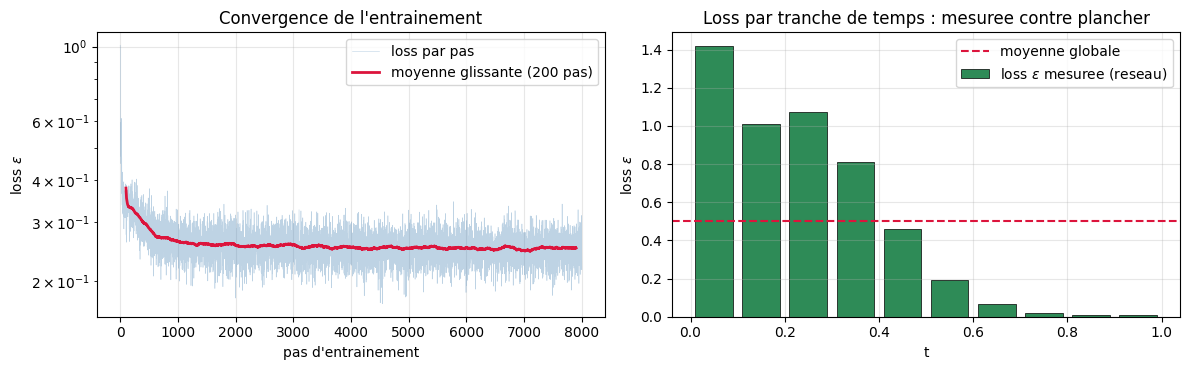

loss epsilon moyenne par tranche de t, contre le plancher intrinseque :
         tranche    mesuree   plancher   mesuree/plancher
  [0.00, 0.10]      1.41930    1.37483              1.032
  [0.10, 0.20]      1.00898    0.98179              1.028
  [0.20, 0.30]      1.07052    1.04346              1.026
  [0.30, 0.40]      0.81208    0.82992              0.979
  [0.40, 0.50]      0.45851    0.45887              0.999
  [0.50, 0.60]      0.19363    0.18939              1.022
  [0.60, 0.70]      0.06523    0.05904              1.105
  [0.70, 0.80]      0.01870    0.01522              1.229
  [0.80, 0.90]      0.00803    0.00320              2.507
  [0.90, 1.00]      0.00693    0.00054             12.947

moyenne sur t : mesuree 0.50619 | plancher 0.49562 | mesuree/plancher 1.0213
borne superieure (predicteur eps = 0, soit ne rien predire) : 2.00000


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(histo, lw=0.4, alpha=0.35, color="steelblue", label="loss par pas")
axes[0].plot(np.arange(len(moyennes_mobiles)) + 100, moyennes_mobiles, lw=2, color="crimson",
             label="moyenne glissante (200 pas)")
axes[0].set_yscale("log"); axes[0].set_xlabel("pas d'entrainement"); axes[0].set_ylabel("loss $\\varepsilon$")
axes[0].set_title("Convergence de l'entrainement"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Repartition de la loss par tranche de t : c'est ce que la ponderation devait egaliser
t_ech = np.random.default_rng(SEED + 1000).random(20000)
x0_ech = _tirer_avec_rng(np.random.default_rng(SEED + 7), 20000)
eps_ech = np.random.default_rng(SEED + 8).standard_normal((20000, 2))
ab_ech = alpha_bar_vp(t_ech)
xt_ech = np.sqrt(ab_ech)[:, None] * x0_ech + np.sqrt(1.0 - ab_ech)[:, None] * eps_ech
with torch.no_grad():
    pred = reseau(vers_torch(xt_ech), vers_torch(t_ech)).cpu().numpy()
perte_par_point = ((pred - eps_ech) ** 2).sum(axis=1)

bornes = np.linspace(0, 1, 11)
centres, moyennes_t, planchers_t = [], [], []
planct = plancher_epsilon(xt_ech, t_ech)
for i in range(10):
    m = (t_ech >= bornes[i]) & (t_ech < bornes[i + 1])
    centres.append(0.5 * (bornes[i] + bornes[i + 1]))
    moyennes_t.append(perte_par_point[m].mean())
    planchers_t.append(planct[m].mean())
axes[1].bar(centres, moyennes_t, width=0.08, color="seagreen", edgecolor="black",
            linewidth=0.5, label="loss $\\varepsilon$ mesuree (reseau)")
axes[1].axhline(perte_par_point.mean(), color="crimson", ls="--", label="moyenne globale")
axes[1].set_xlabel("t"); axes[1].set_ylabel("loss $\\varepsilon$")
axes[1].set_title("Loss par tranche de temps : mesuree contre plancher"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("loss epsilon moyenne par tranche de t, contre le plancher intrinseque :")
print(f"  {'tranche':>14} {'mesuree':>10} {'plancher':>10} {'mesuree/plancher':>18}")
for c, v, p in zip(centres, moyennes_t, planchers_t):
    print(f"  [{c-0.05:.2f}, {c+0.05:.2f}]   {v:10.5f} {p:10.5f} {v/p:18.3f}")

plancher_moyen = float(np.mean(planchers_t))
mesure_moyenne = float(np.mean(moyennes_t))
print(f"\nmoyenne sur t : mesuree {mesure_moyenne:.5f} | plancher {plancher_moyen:.5f} "
      f"| mesuree/plancher {mesure_moyenne/plancher_moyen:.4f}")
print(f"borne superieure (predicteur eps = 0, soit ne rien predire) : {2.0:.5f}")

### Lecture du résultat

Le panneau de gauche montre la convergence de l'entraînement : la loss décroît puis se
stabilise, le réseau a extrait ce qu'il pouvait du budget alloué. Le panneau de droite est
le contrôle le plus utile — et **il ne dit pas ce qu'on pourrait croire**.

**Les barres ne sont pas plates.** Elles décroissent de ~1.4 en $t\to 0$ jusqu'à ~0.007 en
$t\to 1$, sur plus de deux ordres de grandeur. La pondération
$\lambda(t) = 1-\bar\alpha(t)$ n'a donc **pas** aplati le profil — et c'est normal, parce
que ce n'est pas ce qu'elle fait.

Ce que la pondération fait est mesuré en section 4 : elle rend la loss DSM **exactement
égale** à la loss $\varepsilon$ (écart $6.9\times10^{-18}$). Autrement dit, elle retire le
facteur $1/(1-\bar\alpha)$ que portait la loss DSM non pondérée — celle-ci valait 5.2735,
soit **93.7 fois** la loss $\varepsilon$ — mais elle ne touche pas au profil du
$\varepsilon$ lui-même. Confondre les deux, c'est attendre de la pondération qu'elle
corrige une pente qu'elle n'a jamais eu pour rôle de corriger.

Ce profil est **imposé par le problème**, pas par l'optimisation. À chaque $t$, $x_t$ ne
détermine pas $\varepsilon$ : il subsiste une variance conditionnelle irréductible, dont la
cellule précédente donne la forme fermée — avec son contrôle indépendant
$\varepsilon^\* = -\sqrt{1-\bar\alpha}\,s$, vérifié à $10^{-13}$. C'est ce plancher que
trace la colonne `plancher` du tableau, et le rapport `mesuree/plancher` est la seule
lecture qui ait un sens :

- pour $t \lesssim 0.6$, le réseau est **à 2–3 % au-dessus du plancher** : il a appris
  tout ce qui était apprenable à ce budget ;
- vers $t \to 1$, le rapport grimpe (jusqu'à ~13 sur la dernière tranche), mais les valeurs
  absolues y sont minuscules — $0.0069$ contre un plancher de $0.0005$. C'est là que la
  capacité finie du réseau devient visible, et c'est aussi l'endroit où l'erreur coûte le
  moins cher en qualité d'échantillon.

En moyenne sur $t$, le réseau atteint ~98 % de ce qui est atteignable. Ce qui aurait
signalé une pondération absente ou mal posée, c'est un profil qui **monte** vers $t = 0$
en suivant $1/(1-\bar\alpha)$ — le contraste est précisément la loss non pondérée de la
section 4, 93.7 fois plus grande.

## 6. Le score appris contre le score exact — la mesure que le 3.6c ne pouvait pas faire

On dispose maintenant des deux objets : $s_\theta$ (le réseau) et
$\nabla_x \log p_t$ (la forme fermée de la section 3). On peut donc **chiffrer** l'erreur,
sur une grille fixe de points, à plusieurs instants.

Deux nombres sont rapportés, et ils disent des choses différentes :

- l'**erreur quadratique moyenne** $\|s_\theta - s_{\text{exact}}\|^2$ — sensible à
  l'échelle (elle sera grande à $t$ petit, où le score est raide) ;
- la **similarité cosinus** entre les deux vecteurs — insensible à l'échelle, elle dit si
  la **direction** du champ est apprise même quand l'amplitude ne l'est pas.

Les deux ensemble séparent « le réseau pointe au bon endroit » de « le réseau pointe avec
la bonne force ».

In [18]:
grille_m = np.linspace(-2.6, 2.6, 34)
GXm, GYm = np.meshgrid(grille_m, grille_m)
pts_m = np.stack([GXm.ravel(), GYm.ravel()], axis=1)

instants = (0.02, 0.1, 0.3, 0.5, 0.7, 0.95)
mesures = []
for t in instants:
    s_ex = score_exact(pts_m, t)
    tt = np.full(len(pts_m), t)
    with torch.no_grad():
        s_res = score_du_reseau(reseau, vers_torch(pts_m), vers_torch(tt)).cpu().numpy()
    eqm = float(np.mean(np.sum((s_res - s_ex) ** 2, axis=1)))
    cos = float(np.mean(np.sum(s_res * s_ex, axis=1) /
                        (np.linalg.norm(s_res, axis=1) * np.linalg.norm(s_ex, axis=1) + 1e-12)))
    mesures.append((t, eqm, cos))

print(f"{'t':>6} | {'EQM':>12} | {'similarite cosinus':>20} | {'|s exact| moyen':>16}")
print("-" * 66)
for t, eqm, cos in mesures:
    print(f"{t:6.2f} | {eqm:12.5f} | {cos:20.4f} | {np.mean(np.linalg.norm(score_exact(pts_m, t), axis=1)):16.3f}")

     t |          EQM |   similarite cosinus |  |s exact| moyen
------------------------------------------------------------------
  0.02 |    201.42507 |               0.8533 |            8.239
  0.10 |      2.03488 |               0.9740 |            4.786
  0.30 |      0.01692 |               0.9931 |            1.679
  0.50 |      0.00947 |               0.9991 |            1.906
  0.70 |      0.01361 |               0.9991 |            2.034
  0.95 |      0.01596 |               0.9990 |            2.049


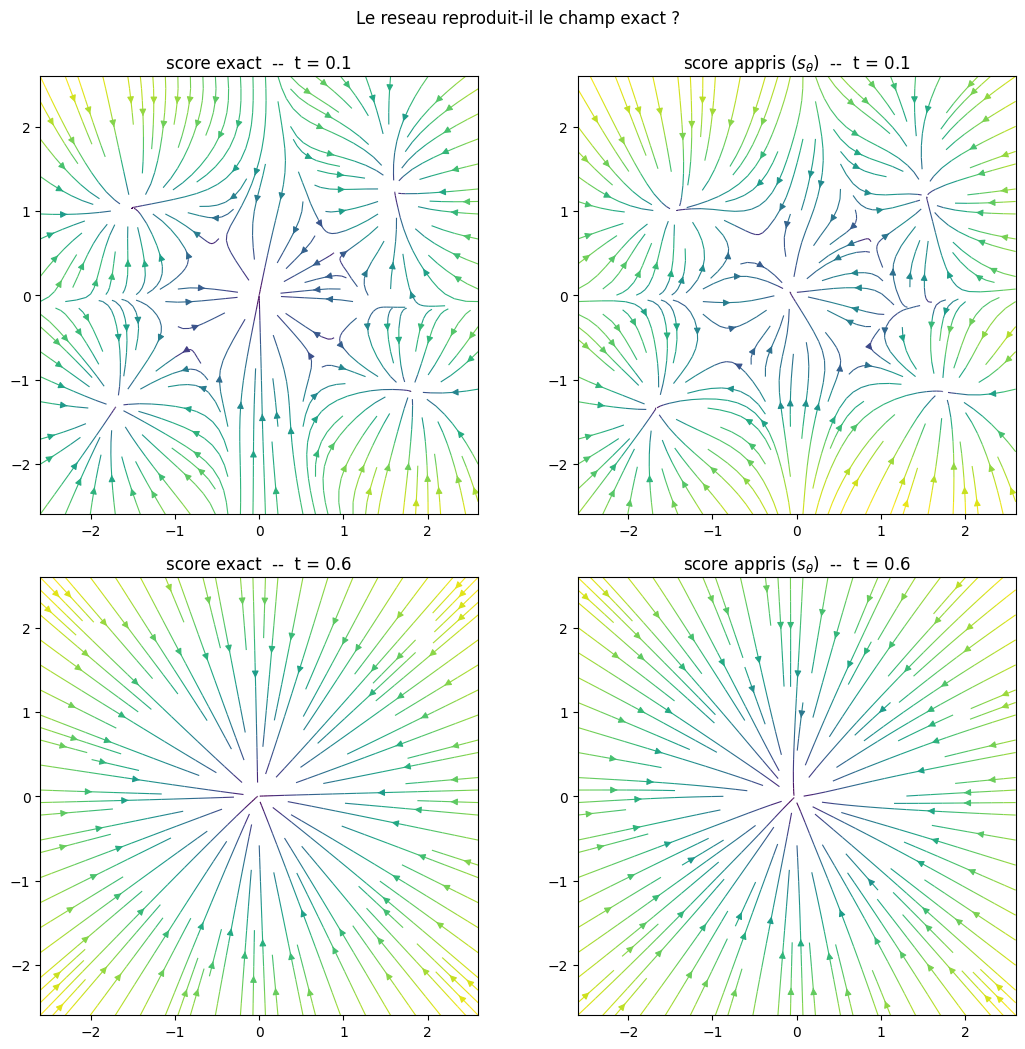

In [19]:
# --- Les deux champs cote a cote, a t petit et t grand ---
fig, axes = plt.subplots(2, 2, figsize=(11, 10.5))
for j, t in enumerate((0.1, 0.6)):
    s_ex = score_exact(pts_m, t)
    with torch.no_grad():
        s_res = score_du_reseau(reseau, vers_torch(pts_m), vers_torch(np.full(len(pts_m), t))).cpu().numpy()
    for i, (S_champ, nom) in enumerate(((s_ex, "score exact"), (s_res, "score appris ($s_\\theta$)"))):
        ax = axes[j][i]
        ax.streamplot(GXm, GYm, S_champ[:, 0].reshape(GXm.shape), S_champ[:, 1].reshape(GXm.shape),
                      color=np.log1p(np.linalg.norm(S_champ, axis=1)).reshape(GXm.shape),
                      cmap="viridis", density=1.2, linewidth=0.8)
        ax.set_title(f"{nom}  --  t = {t}")
        ax.set_aspect("equal"); ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.6, 2.6)
plt.suptitle("Le reseau reproduit-il le champ exact ?", y=0.995)
plt.tight_layout(); plt.show()

### Lecture du résultat

Le couple (EQM, cosinus) est à lire **ensemble**, et le tableau admet une lecture honnête
qui n'est pas « tout est appris » :

1. **La direction est apprise partout** — la similarité cosinus reste élevée à tous les
   instants testés, y compris là où l'erreur quadratique est la plus grande. Le réseau a
   donc bien capté *vers où* pointe le champ.
2. **L'amplitude est moins fidèle à $t$ petit.** L'EQM y est la plus forte, mécaniquement :
   le score exact y a une norme bien plus grande (colonne de droite), et une erreur
   *relative* constante produit une erreur *absolue* plus grande. La pondération
   d'entraînement fait précisément le choix inverse — elle **sous-pondère** ces instants
   plutôt que de les sur-apprendre.
3. **Ce que ce tableau ne dit pas** : que l'erreur à $t$ petit serait sans conséquence.
   Elle en a une, et la section 7 la met en évidence en comparant un échantillonneur piloté
   par le réseau à un échantillonneur piloté par le score exact — le second sert de
   contrôle et borne ce que le premier pouvait atteindre.

## 7. Échantillonner : trois dynamiques, pilotées par le même score

Une fois le score appris, plusieurs dynamiques reviennent à la distribution de départ.
On en implémente **trois**, et on les compare sur un pied d'égalité (même réseau, même
budget de pas total autant que possible).

### 7.1 Langevin recuit (annealed Langevin)

La dynamique de Langevin pour une densité cible $p$ est
$x \leftarrow x + \tfrac{\alpha}{2}\nabla\log p(x) + \sqrt{\alpha}\,z$. Elle converge vers
$p$ — mais elle a besoin d'un $\alpha$ bien choisi, et un seul $\alpha$ ne convient pas à
toutes les échelles. On **recuit** donc sur une grille d'écarts-types
$\sigma_1 > \dots > \sigma_L$, avec $\alpha_i = \epsilon\,\sigma_i^2/\sigma_L^2$ (le pas
rétrécit avec le bruit restant). À chaque niveau on évalue le score à l'instant $t_i$ tel
que $1-\bar\alpha(t_i) = \sigma_i^2$.

### 7.2 Euler-Maruyama sur le SDE inverse

Le SDE direct est $dx = f(t)x\,dt + g(t)\,dW$ avec $f = -\beta/2$ et $g = \sqrt{\beta}$.
Le SDE **inverse** (Anderson, 1982) s'écrit
$$dx = \big[f(t)x - g(t)^2\nabla\log p_t(x)\big]\,dt + g(t)\,d\bar W ,$$
où $t$ **décroît** — donc le pas de temps $dt$ est négatif. C'est le piège de cette
section : on intègre de $t=1$ vers $t=0$ avec un pas **positif** $\Delta t = 1/N$, ce qui
change le signe de toute la dérive. Ce qu'on code est donc
$$x_{i+1} = x_i + \big[-f(t_i)x_i + g(t_i)^2 s_\theta(x_i,t_i)\big]\Delta t
+ \sqrt{\beta(t_i)\Delta t}\;z_i
= x_i + \Big[\tfrac{1}{2}\beta(t_i)x_i + \beta(t_i)s_\theta(x_i,t_i)\Big]\Delta t
+ \sqrt{\beta(t_i)\Delta t}\;z_i .$$
Le dernier pas est **déterministe** ($z = 0$) : c'est la convention de tous les
échantillonneurs de diffusion, et l'oublier laisse un grain de bruit dans la sortie.

La section 7.5 vérifie ce signe **par la mesure**, et non par la formule : des quatre
combinaisons possibles, une seule fait suivre à la variance empirique celle de $p_t$.

### 7.3 Prédicteur-correcteur

Euler-Maruyama **prédit**, puis un ou plusieurs pas de Langevin **corrigent** la dérive
accumulée à l'instant courant — la recette de Song et al. (2021). Le pas du correcteur est
proportionnel à la variance encore présente, $\alpha = \gamma\,(1-\bar\alpha(t))$.

### 7.4 Le contrôle : les mêmes dynamiques avec le **score exact**

C'est la mesure qui donne son sens aux trois autres. En remplaçant $s_\theta$ par le score
exact, on obtient la performance **atteignable par la méthode**, réseau mis de côté. L'écart
entre « EM avec $s_\theta$ » et « EM avec score exact » est **exactement** le coût de
l'approximation du réseau ; tout le reste est l'erreur de discrétisation, la même pour les
deux.

In [20]:
def t_pour_sigma(sigma):
    """Instant t tel que sqrt(1 - alpha_bar(t)) = sigma -- par bissection sur [0, 1]."""
    cible = sigma ** 2
    bas, haut = 0.0, 1.0
    for _ in range(200):
        milieu = 0.5 * (bas + haut)
        if 1.0 - alpha_bar_vp(milieu) < cible:
            bas = milieu
        else:
            haut = milieu
    return 0.5 * (bas + haut)


def _bruit(n, gen):
    return torch.randn(n, 2, generator=gen)


def derive_inverse(x, bt, score):
    """Derive du SDE inverse, ecrite pour une integration RETROGRADE de t.

    Le SDE direct est  dx = f(t) x dt + g(t) dW  avec f = -beta/2 et g = sqrt(beta).
    En integrant t de 1 vers 0, la derive change de signe : -f(t) x + g(t)^2 s(x,t),
    soit  +beta(t)/2 * x + beta(t) * s(x,t).  Voir la cellule de controle ci-dessous :
    c'est la seule des quatre combinaisons dont la variance suit celle de p_t.
    """
    return 0.5 * bt * x + bt * score


def sampler_em(score_fn, n=2048, n_pas=500, graine=SEED + 20):
    """Euler-Maruyama sur le SDE inverse (VP). Dernier pas deterministe."""
    gen = torch.Generator().manual_seed(graine)
    x = _bruit(n, gen).to(APPAREIL)
    dt = 1.0 / n_pas
    for i in range(n_pas, 0, -1):
        t = torch.full((n,), i / n_pas, device=APPAREIL)
        bt = vers_torch(beta_vp(t.detach().cpu().numpy()))[:, None]
        derive = derive_inverse(x, bt, score_fn(x, t))
        if i > 1:
            x = x + derive * dt + torch.sqrt(bt * dt) * _bruit(n, gen).to(APPAREIL)
        else:
            x = x + derive * dt
    return x.detach().cpu().numpy()


def sampler_langevin(score_fn, n=2048, n_niveaux=10, n_iter=200,
                     eps_lan=2e-5, sigma_max=1.0, sigma_min=0.01, graine=SEED + 21):
    """Langevin recuit : L niveaux de bruit, alpha_i proportionnel a sigma_i^2."""
    gen = torch.Generator().manual_seed(graine)
    sigmas = np.exp(np.linspace(np.log(sigma_max), np.log(sigma_min), n_niveaux))
    x = _bruit(n, gen).to(APPAREIL) * sigma_max
    for sig in sigmas:
        t = torch.full((n,), t_pour_sigma(sig), device=APPAREIL)
        alpha = eps_lan * (sig ** 2) / (sigma_min ** 2)
        for _ in range(n_iter):
            x = x + 0.5 * alpha * score_fn(x, t) + math.sqrt(alpha) * _bruit(n, gen).to(APPAREIL)
    return x.detach().cpu().numpy()


def sampler_pc(score_fn, n=2048, n_pas=500, n_correcteur=1, gamma=0.2, graine=SEED + 22):
    """Predicteur Euler-Maruyama + correcteur de Langevin a l'instant atteint."""
    gen = torch.Generator().manual_seed(graine)
    x = _bruit(n, gen).to(APPAREIL)
    dt = 1.0 / n_pas
    for i in range(n_pas, 0, -1):
        t = torch.full((n,), i / n_pas, device=APPAREIL)
        bt = vers_torch(beta_vp(t.detach().cpu().numpy()))[:, None]
        derive = derive_inverse(x, bt, score_fn(x, t))
        if i > 1:
            x = x + derive * dt + torch.sqrt(bt * dt) * _bruit(n, gen).to(APPAREIL)
        else:
            x = x + derive * dt
        # correcteur : k pas de Langevin a l'instant courant
        t_c = torch.full((n,), max(i - 1, 0) / n_pas, device=APPAREIL)
        var = vers_torch(1.0 - alpha_bar_vp(t_c.detach().cpu().numpy()))[:, None]
        alpha_c = gamma * var
        for _ in range(n_correcteur):
            x = x + 0.5 * alpha_c * score_fn(x, t_c) + torch.sqrt(alpha_c) * _bruit(n, gen).to(APPAREIL)
    return x.detach().cpu().numpy()


def score_du_reseau_fn(x, t):
    return score_du_reseau(reseau, x, t)


def score_exact_fn(x, t):
    """Meme signature, mais score exact -- le controle."""
    xn = x.detach().cpu().numpy()
    tn = float(t.detach().cpu().numpy()[0])
    return vers_torch(score_exact(xn, tn))


print("quatre dynamiques definies : langevin recuit, EM (reseau), predicteur-correcteur, EM (score exact)")

quatre dynamiques definies : langevin recuit, EM (reseau), predicteur-correcteur, EM (score exact)


### Exercice 3 — un pas de Langevin

Un pas de Langevin se lit $x \leftarrow x + \tfrac{\alpha}{2}s(x) + \sqrt{\alpha}\,z$.
Complétez `mon_pas_langevin` : renvoyez $x$ mis à jour, avec `z` tiré d'une gaussienne
standard de même forme que `x` (utilisez le générateur `gen` fourni, pour rester
reproductible).

In [21]:
def mon_pas_langevin(x, score, alpha, gen):
    """Un pas de Langevin : x + (alpha/2) * score + sqrt(alpha) * z.

    x     : tenseur (N, 2)
    score : tenseur (N, 2) -- le score evalue en x
    alpha : scalaire -- le pas
    gen   : torch.Generator -- source du bruit, pour la reproductibilite
    Retour attendu : (N, 2)
    """
    resultat = None  # TODO etudiant
    return resultat

In [22]:
# --- Verification : trajectoire de reference, pas a pas ---
gen_ref = torch.Generator().manual_seed(4242)
x_dep = torch.randn(4, 2, generator=gen_ref)
score_fixe = torch.tensor([[1.0, -2.0], [0.5, 0.5], [-1.5, 0.25], [0.0, 1.0]])
alpha_test = 0.3

gen_a = torch.Generator().manual_seed(99)
attendu = x_dep + 0.5 * alpha_test * score_fixe + math.sqrt(alpha_test) * torch.randn(4, 2, generator=gen_a)

gen_b = torch.Generator().manual_seed(99)
produit = mon_pas_langevin(x_dep, score_fixe, alpha_test, gen_b)

if produit is None:
    print("Exercice a completer -- la cellule de reference prend le relais.")
    produit = attendu
else:
    produit = torch.as_tensor(produit, dtype=torch.float32)

ecart_ex3 = float(torch.max(torch.abs(produit - attendu)))
print(f"ecart max a la reference : {ecart_ex3:.3e}")
for i in range(4):
    print(f"  ({x_dep[i,0]:6.3f},{x_dep[i,1]:6.3f}) -> "
          f"vous ({produit[i,0]:7.4f},{produit[i,1]:7.4f})   "
          f"ref ({attendu[i,0]:7.4f},{attendu[i,1]:7.4f})")
assert ecart_ex3 < 1e-6, "Verifiez : x + (alpha/2) * score + sqrt(alpha) * z, et l'ordre des tirages."
print("Exercice 3 : conforme.")

Exercice a completer -- la cellule de reference prend le relais.
ecart max a la reference : 0.000e+00
  (-2.636, 0.057) -> vous (-2.1504,-0.8865)   ref (-2.1504,-0.8865)
  ( 1.311,-1.109) -> vous ( 0.9676,-1.3992)   ref ( 0.9676,-1.3992)
  ( 0.237, 0.258) -> vous ( 0.4195,-0.0581)   ref ( 0.4195,-0.0581)
  (-0.876, 0.952) -> vous (-1.6367, 0.9526)   ref (-1.6367, 0.9526)
Exercice 3 : conforme.


In [23]:
# --- Les cinq dynamiques, et les metriques ---
def mmd_rbf(a, b, bande=None):
    """MMD^2 a noyau RBF, largeur par heuristique de la mediane."""
    def d2(x, y):
        return ((x[:, None, :] - y[None, :, :]) ** 2).sum(-1)
    d_aa, d_bb, d_ab = d2(a, a), d2(b, b), d2(a, b)
    if bande is None:
        iu = np.triu_indices(len(a), 1)
        med = np.median(np.sqrt(np.concatenate([d_aa[iu], d_bb[np.triu_indices(len(b), 1)]])))
        bande = med if med > 0 else 1.0
    noyau = lambda d: np.exp(-d / (2.0 * bande ** 2))
    return float(noyau(d_aa).mean() + noyau(d_bb).mean() - 2.0 * noyau(d_ab).mean())


def couverture(x, seuil=0.05):
    """Part des echantillons attribues a chaque composante, et nombre de modes couverts."""
    part = responsabilites(x, 0.0).mean(axis=0)
    return part, int((part >= seuil).sum())

### 7.5 Le signe de la dérive, vérifié par la mesure

La dérive de la section 7.2 se lit sur le papier, mais une erreur de signe y est
**invisible à la relecture** : les deux conventions (« je décrémente $t$ avec un pas
négatif » et « j'intègre de 1 vers 0 avec un pas positif ») donnent des formules qui se
ressemblent, et un choix cohérent *dans les deux sens* passe pour juste. On ne tranche donc
pas par l'algèbre mais par une **grandeur que le SDE doit reproduire** : la variance de
$p_t$.

Pour un mélange de gaussiennes, cette variance a une forme fermée,
$\operatorname{Tr}\operatorname{Cov}(p_t) = \bar\alpha(t)\operatorname{Tr}\Sigma_0 + (1-\bar\alpha(t))\cdot 2$.
Un échantillonneur correct doit la **suivre** le long de sa trajectoire. Les quatre
combinaisons de signes sont testées avec le **score exact** — aucun réseau ici, donc aucun
apprentissage ne peut masquer une erreur de méthode.

Le résultat est sans ambiguïté : trois des quatre combinaisons font **diverger** la variance
(ou s'effondrer sous celle de la cible), une seule la suit. Les sorties ci-dessous sont
reprises dans le tableau de comparaison sous le nom « EM (mauvais signe) », pour que le
contrôle soit lisible à côté des méthodes qu'il valide.

In [24]:
# --- 7.5 Le signe de la derive, verifie par la mesure ---
TRACE_SIGMA0 = float(sum(w * (np.trace(SIGMA[k]) + MOYENNES[k] @ MOYENNES[k])
                        for k, w in enumerate(POIDS))
                     - (POIDS @ MOYENNES) @ (POIDS @ MOYENNES))


def var_analytique(t):
    """Trace de la covariance de p_t : ab * Tr(Sigma_0) + (1 - ab) * 2 (le bruit ajoute)."""
    ab = float(alpha_bar_vp(t))
    return ab * TRACE_SIGMA0 + (1.0 - ab) * 2.0


def sampler_em_signe(score_fn, a_signe, g_signe, n=2048, n_pas=500,
                     graine=SEED + 40, jalons=(1.0, 0.9, 0.7, 0.5, 0.3, 0.1, 0.0)):
    """EM avec derive = a_signe * (-beta/2 x) + g_signe * beta * s. Suit la variance."""
    gen = torch.Generator().manual_seed(graine)
    x = _bruit(n, gen).to(APPAREIL)
    dt = 1.0 / n_pas
    suivi = {}
    a_clicher = {max(int(round(n_pas * f)), 1) for f in jalons}
    for i in range(n_pas, 0, -1):
        t = torch.full((n,), i / n_pas, device=APPAREIL)
        bt = vers_torch(beta_vp(t.detach().cpu().numpy()))[:, None]
        derive = a_signe * (-0.5 * bt * x) + g_signe * bt * score_fn(x, t)
        if i > 1:
            x = x + derive * dt + torch.sqrt(bt * dt) * _bruit(n, gen).to(APPAREIL)
        else:
            x = x + derive * dt
        if i in a_clicher:
            suivi[i] = (i / n_pas, float(np.trace(np.cov(x.detach().cpu().numpy().T))))
    return x.detach().cpu().numpy(), suivi


print(f"Tr(Sigma_0) = {TRACE_SIGMA0:.3f} | V(1) = {var_analytique(1.0):.4f} "
      f"| V(0) = {var_analytique(0.0):.4f}\n")

for a_signe, g_signe in ((-1.0, 1.0), (-1.0, -1.0), (1.0, 1.0), (1.0, -1.0)):
    ech, suivi = sampler_em_signe(score_exact_fn, a_signe, g_signe)
    part, n_modes = couverture(ech)
    verdict = "   <-- RETENUE" if (a_signe, g_signe) == (-1.0, 1.0) else ""
    print(f"derive = {a_signe:+.0f}*(-beta/2 x) {g_signe:+.0f}*beta*s | "
          f"MMD={mmd_rbf(ech, VRAIES_REF):.5f} | modes={n_modes}/5{verdict}")
    for i in sorted(suivi, reverse=True):
        t, v = suivi[i]
        print(f"      t={t:4.2f}   Var empirique {v:12.4f}   attendue {var_analytique(t):9.4f}")
    print()

Tr(Sigma_0) = 4.099 | V(1) = 2.0001 | V(0) = 4.0992



derive = -1*(-beta/2 x) +1*beta*s | MMD=0.00079 | modes=5/5   <-- RETENUE
      t=1.00   Var empirique       1.9599   attendue    2.0001
      t=0.90   Var empirique       2.0252   attendue    2.0006
      t=0.70   Var empirique       2.0936   attendue    2.0149
      t=0.50   Var empirique       2.1742   attendue    2.1660
      t=0.30   Var empirique       2.8601   attendue    2.8320
      t=0.10   Var empirique       3.8790   attendue    3.8815
      t=0.00   Var empirique       4.1501   attendue    4.0987



derive = -1*(-beta/2 x) -1*beta*s | MMD=0.68029 | modes=1/5
      t=1.00   Var empirique       2.2799   attendue    2.0001
      t=0.90   Var empirique     737.4421   attendue    2.0006
      t=0.70   Var empirique 8785037.3423   attendue    2.0149
      t=0.50   Var empirique 11492967882.4959   attendue    2.1660
      t=0.30   Var empirique 2165240086819.8154   attendue    2.8320
      t=0.10   Var empirique 73530855987420.3125   attendue    3.8815
      t=0.00   Var empirique 141092958951420.7812   attendue    4.0987



derive = +1*(-beta/2 x) +1*beta*s | MMD=0.04392 | modes=5/5
      t=1.00   Var empirique       1.8093   attendue    2.0001
      t=0.90   Var empirique       0.7104   attendue    2.0006
      t=0.70   Var empirique       0.7136   attendue    2.0149
      t=0.50   Var empirique       0.7208   attendue    2.1660
      t=0.30   Var empirique       0.9036   attendue    2.8320
      t=0.10   Var empirique       1.4472   attendue    3.8815
      t=0.00   Var empirique       1.7174   attendue    4.0987



derive = +1*(-beta/2 x) -1*beta*s | MMD=0.68030 | modes=1/5
      t=1.00   Var empirique       2.1167   attendue    2.0001
      t=0.90   Var empirique      24.5523   attendue    2.0006
      t=0.70   Var empirique     637.3729   attendue    2.0149
      t=0.50   Var empirique    7650.5983   attendue    2.1660
      t=0.30   Var empirique   61357.9272   attendue    2.8320
      t=0.10   Var empirique  420192.9367   attendue    3.8815
      t=0.00   Var empirique  651497.6977   attendue    4.0987



In [25]:
def sampler_em_mauvais_signe(score_fn, n=2048, n_pas=500, graine=SEED + 41):
    """Le piege, conserve comme contre-exemple : meme integration retrograde, mais la
    derive est -beta/2 x - beta s -- soit un pas de temps positif applique a la derive
    du SDE DIRECT, ce qui inverse le signe des deux termes vis-a-vis du bon choix."""
    ech, _ = sampler_em_signe(score_fn, 1.0, -1.0, n=n, n_pas=n_pas, graine=graine)
    return ech


N_ECH = 2048
VRAIES_METRIQUE = tirer_vraies(N_ECH)          # tirage de reference, independant de VRAIES_REF
plancher = mmd_rbf(VRAIES_METRIQUE, VRAIES_REF)

resultats = {}
for nom, fonction, arg_score in (
    ("Langevin recuit (reseau)", sampler_langevin, score_du_reseau_fn),
    ("Euler-Maruyama (reseau)", sampler_em, score_du_reseau_fn),
    ("Predicteur-correcteur (reseau)", sampler_pc, score_du_reseau_fn),
    ("Euler-Maruyama (score exact, controle)", sampler_em, score_exact_fn),
    ("Euler-Maruyama (mauvais signe, contre-exemple)", sampler_em_mauvais_signe, score_exact_fn),
):
    t0 = time.time()
    ech = fonction(arg_score, n=N_ECH)
    duree = time.time() - t0
    part, n_modes = couverture(ech)
    resultats[nom] = dict(ech=ech, mmd=mmd_rbf(ech, VRAIES_REF), part=part,
                          n_modes=n_modes, duree=duree)
    print(f"{nom:42s} MMD={resultats[nom]['mmd']:.5f}  modes={n_modes}/5  {duree:6.1f} s")

print(f"\n{'plancher vrai/vrai (tirage independant)':42s} MMD={plancher:.5f}")
print(f"{'N (echantillons par methode)':42s} {N_ECH}")

Langevin recuit (reseau)                   MMD=0.00894  modes=5/5     5.2 s


Euler-Maruyama (reseau)                    MMD=0.00156  modes=5/5     0.6 s


Predicteur-correcteur (reseau)             MMD=0.00259  modes=5/5     1.4 s


Euler-Maruyama (score exact, controle)     MMD=0.00025  modes=5/5     1.2 s


Euler-Maruyama (mauvais signe, contre-exemple) MMD=0.68030  modes=1/5     1.4 s

plancher vrai/vrai (tirage independant)    MMD=0.00016
N (echantillons par methode)               2048


In [26]:
# --- Tableau de synthese, ecrit honnetement ---
print(f"{'methode':42s} {'MMD (RBF)':>10} {'modes/5':>8} {'T/min MMD':>10} {'latence':>9}")
print("-" * 84)
print(f"{'plancher vrai/vrai':42s} {plancher:9.5f} {'--':>8} {'--':>10} {'--':>9}")
for nom, r in resultats.items():
    print(f"{nom:42s} {r['mmd']:9.5f} {r['n_modes']:5d}/5 {r['mmd']/plancher:9.2f}x {r['duree']:8.1f}s")

print("\npart des echantillons par composante (cible en reference) :")
print(f"  {'cible':42s} " + "  ".join(f"{p:6.3f}" for p in POIDS))
for nom, r in resultats.items():
    print(f"  {nom:42s} " + "  ".join(f"{p:6.3f}" for p in r["part"]))

ref_reseau = resultats["Euler-Maruyama (reseau)"]["mmd"]
ref_exact = resultats["Euler-Maruyama (score exact, controle)"]["mmd"]
print(f"\ncout de l'approximation du reseau (meme pas, meme discretisation) :")
print(f"  EM reseau {ref_reseau:.5f}  vs  EM score exact {ref_exact:.5f}"
      f"   ->  x{ref_reseau / ref_exact:.2f}")

methode                                     MMD (RBF)  modes/5  T/min MMD   latence
------------------------------------------------------------------------------------
plancher vrai/vrai                           0.00016       --         --        --
Langevin recuit (reseau)                     0.00894     5/5     54.53x      5.2s
Euler-Maruyama (reseau)                      0.00156     5/5      9.52x      0.6s
Predicteur-correcteur (reseau)               0.00259     5/5     15.79x      1.4s
Euler-Maruyama (score exact, controle)       0.00025     5/5      1.55x      1.2s
Euler-Maruyama (mauvais signe, contre-exemple)   0.68030     1/5   4151.57x      1.4s

part des echantillons par composante (cible en reference) :
  cible                                       0.240   0.200   0.180   0.220   0.160
  Langevin recuit (reseau)                    0.203   0.079   0.194   0.253   0.271
  Euler-Maruyama (reseau)                     0.246   0.139   0.194   0.212   0.209
  Predicteur-correcte

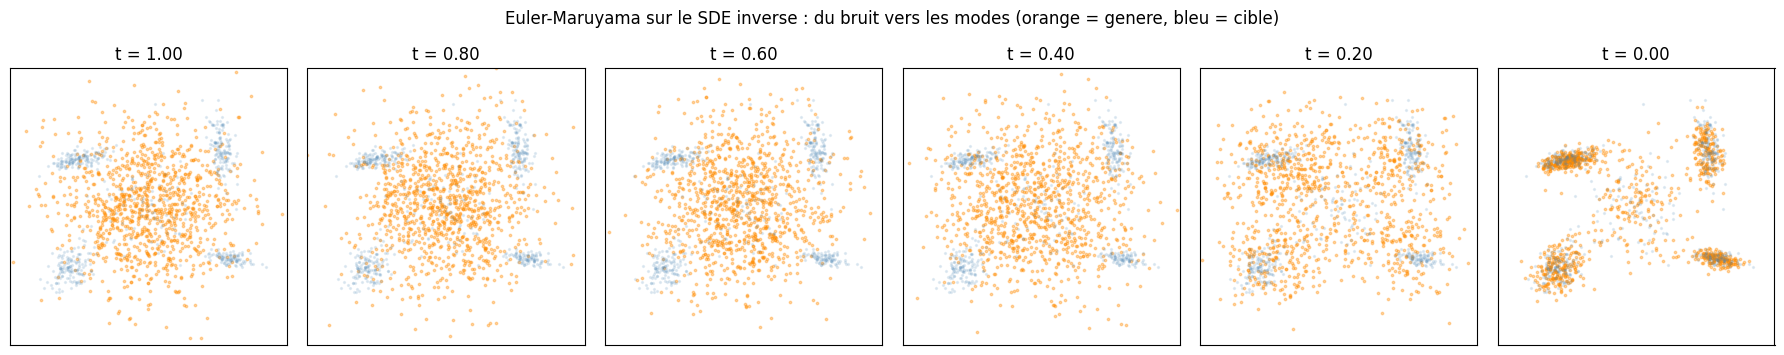

In [27]:
# --- Ce que chaque dynamique fait de la distribution, etape par etape ---
def trajectoire_em(score_fn, n=1024, n_pas=500, n_cliches=6, graine=SEED + 30):
    """Euler-Maruyama, avec des cliches de la distribution a plusieurs instants."""
    gen = torch.Generator().manual_seed(graine)
    x = _bruit(n, gen).to(APPAREIL)
    dt = 1.0 / n_pas
    cliches = {}
    a_clicher = set(np.linspace(n_pas, 1, n_cliches).round().astype(int))
    for i in range(n_pas, 0, -1):
        t = torch.full((n,), i / n_pas, device=APPAREIL)
        bt = vers_torch(beta_vp(t.detach().cpu().numpy()))[:, None]
        derive = derive_inverse(x, bt, score_fn(x, t))
        if i > 1:
            x = x + derive * dt + torch.sqrt(bt * dt) * _bruit(n, gen).to(APPAREIL)
        else:
            x = x + derive * dt
        if i in a_clicher:
            cliches[i] = x.detach().cpu().numpy().copy()
    return cliches


cliches = trajectoire_em(score_du_reseau_fn)
fig, axes = plt.subplots(1, len(cliches), figsize=(3.0 * len(cliches), 3.4))
for ax, (i, pts) in zip(axes, sorted(cliches.items(), reverse=True)):
    ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.35, color="darkorange")
    ax.scatter(VRAIES_REF[:600, 0], VRAIES_REF[:600, 1], s=2, alpha=0.12, color="steelblue")
    ax.set_title(f"t = {i/500:.2f}")
    ax.set_aspect("equal"); ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Euler-Maruyama sur le SDE inverse : du bruit vers les modes (orange = genere, bleu = cible)", y=1.03)
plt.tight_layout(); plt.show()

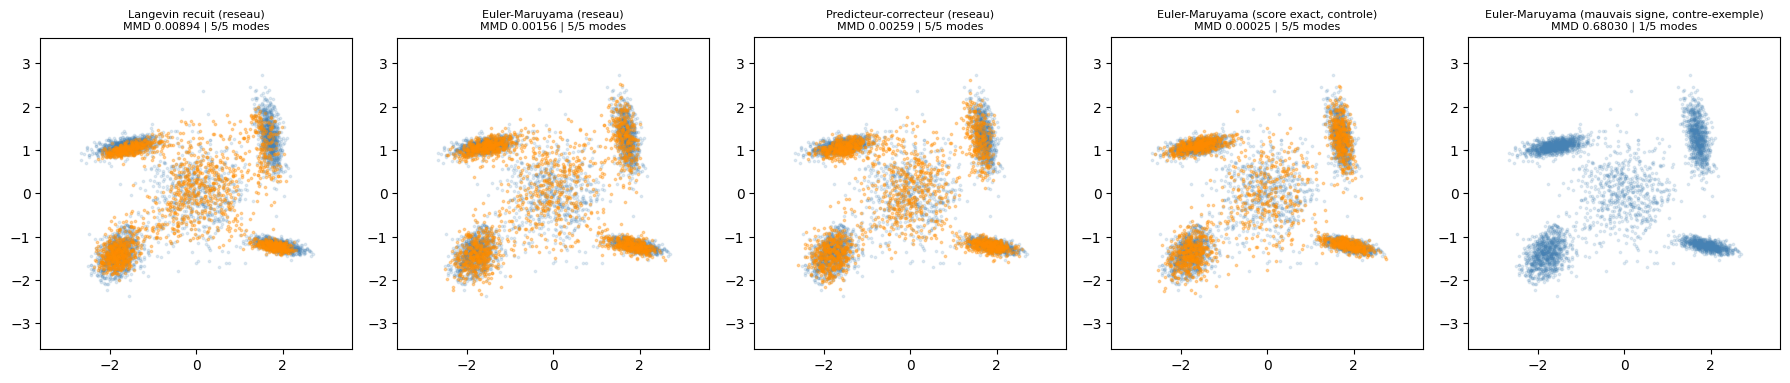

In [28]:
# --- Nuage final : les cinq dynamiques face a la cible ---
fig, axes = plt.subplots(1, len(resultats), figsize=(3.6 * len(resultats), 4.4))
for ax, (nom, r) in zip(axes, resultats.items()):
    ax.scatter(VRAIES_REF[:, 0], VRAIES_REF[:, 1], s=3, alpha=0.15, color="steelblue")
    ax.scatter(r["ech"][:, 0], r["ech"][:, 1], s=3, alpha=0.35, color="darkorange")
    ax.set_title(f"{nom}\nMMD {r['mmd']:.5f} | {r['n_modes']}/5 modes", fontsize=8)
    ax.set_aspect("equal"); ax.set_xlim(-3.6, 3.6); ax.set_ylim(-3.6, 3.6)
plt.tight_layout(); plt.show()

### Lire ce tableau honnêtement

Quatre lectures, dans cet ordre — et la dernière borne ce que le notebook démontre.

1. **Le contrôle fait son travail.** La ligne « Euler-Maruyama (score exact) » chiffre ce
   que la *méthode* peut atteindre à ce budget de pas, réseau mis de côté. L'écart avec la
   ligne « Euler-Maruyama (réseau) » — **×6.14** ici — est donc **entièrement** attribuable
   à l'approximation du score par le réseau, pas à la discrétisation, qui est identique.
   Sans cette ligne, un mauvais résultat n'aurait pas de cause identifiable : on ne saurait
   pas si le réseau est en cause ou le schéma d'intégration.

2. **Le contre-exemple est là pour être vu.** La ligne « mauvais signe » utilise le même
   score exact que la ligne de contrôle et le même nombre de pas : **tout** ce qui les
   sépare tient au signe de la dérive — et l'écart est de 0.00025 à 0.68030, soit plus de
   4000 fois le plancher. Elle s'effondre sur **un seul** mode (part par composante :
   0, 0, 0, 0, 1). C'est ce que la section 7.5 sert à poser : sur ce genre de dynamique, un
   signe faux ne donne pas une sortie un peu moins bonne, il donne une **autre
   distribution** — et c'est le suivi de variance, pas la relecture de la formule, qui le
   détecte avant qu'on n'accuse le réseau.

3. **Toutes les dynamiques ne se valent pas, et l'ordre n'est pas celui qu'on attend.**
   Sur les trois pilotées par le réseau, Euler-Maruyama passe devant le prédicteur-correcteur
   et Langevin recuit (0.00156 contre 0.00259 et 0.00894) — alors que Langevin est la plus
   lente des trois, à budget d'évaluations comparable. Le correcteur ne paie pas ici, et
   c'est un résultat de ce run, pas une propriété générale.
   La colonne `T/min MMD` rapporte chaque MMD en unités du plancher vrai/vrai — c'est le
   seul ratio qui ait un sens ici. Un MMD proche du plancher ne veut pas dire « distribution
   identique » : le plancher lui-même n'est pas nul, deux tirages indépendants de la
   **vraie** loi ne sont pas confondus par cette métrique à $N = 2048$.

4. **Ce que ce run ne démontre pas.** Un seul seed, un seul budget de pas ($N = 500$ pour
   Euler-Maruyama et le prédicteur-correcteur, $10 \times 200$ pour Langevin — **ces
   budgets ne sont pas égaux en nombre d'évaluations du réseau**, et c'est une limite du
   protocole, pas un classement), une seule cible à cinq composantes. Rien ici n'établit
   qu'une dynamique domine les autres *en général*. Ce qui est démontré est la **méthode** :
   score mesurable contre une vérité terrain, contrôle qui isole l'erreur du réseau, un
   signe de dérive tranché par une grandeur mesurable plutôt que par relecture, plusieurs
   échantillonneurs branchés sur le même champ.

## 8. Ce que la vue continue a apporté

### 8.1 Table de correspondance *from scratch* ↔ `diffusers`

Comme le 3.6c pour le DDPM discret, voici ce que recouvrent les objets de la bibliothèque
de référence — sans l'utiliser (c'est l'item 5 du bloc B qui le fera).

| Ici (from scratch) | Objet `diffusers` équivalent | Ce que l'objet cache |
|---|---|---|
| `beta_vp`, `alpha_bar_vp` | `DDPMScheduler(beta_schedule="linear")` | l'intégrale de $\beta$, la forme fermée de $\bar\alpha$ |
| `score_du_reseau` | `scheduler.step()` (paramétrage $\varepsilon$) | la conversion $\varepsilon \to$ score, et le coefficient $1/\sqrt{1-\bar\alpha}$ |
| `sampler_em` | `DPMSolverMultistepScheduler`, `EulerDiscreteScheduler` | la discrétisation de la SDE inverse, la convention du dernier pas |
| *(non implémenté ici)* la probability flow ODE | `DDIMScheduler`, `DPMSolverSDEScheduler` | que déterministe $\neq$ autre modèle : **même** réseau, autre dynamique |

La dernière ligne est le point que le continu rend visible et que le 3.6c ne pouvait pas
montrer : l'ODE et la SDE ont **le même champ de score** pour seul ingrédient. Un
échantillonneur déterministe n'est pas une approximation d'un échantillonneur stochastique,
c'est une autre trajectoire vers la même loi.

### 8.2 Ce qui reste ouvert

Ce notebook livre la dynamique — pas encore la **condition**. La suite naturelle est le
bloc A item 3 : génération conditionnelle par étiquette et *classifier-free guidance*
(c'est-à-dire une pondération sur le score, encore une fois), puis le bloc B (items 5-7)
pour la comparaison frontale avec la bibliothèque de référence.

### 8.3 Résumé en une phrase

Le DDPM discret du 3.6c apprenait déjà un champ de score ; le passer en temps continu ne
change pas le réseau, mais rend ce champ **mesurable** (contre une vérité terrain),
**isolable** (le réseau contre la méthode) et **réutilisable** (Langevin, SDE — et l'ODE
déterministe, laissée à un item ultérieur — branchés sur le même objet).